In [14]:
# Import libraries
import pandas as pd

# Import graphing libraries
import matplotlib.pyplot as plt
import seaborn as sns  # Theme
import pickle
from matplotlib.dates import  MonthLocator, DateFormatter
from pathlib import Path
import sys
import os
sys.path.append(str(Path(os.getcwd()).parent))
from utils.wrappers import measure_time_and_space, measure_time
from utils.data_structures import RollingMeanArray

In [15]:
import warnings
warnings.filterwarnings("ignore")

In [16]:
# --- Import dataset ---
dataset = pd.read_csv("../data/mag7_stocks.csv", parse_dates=["Date"])
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1348 entries, 0 to 1347
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Date          1348 non-null   datetime64[ns]
 1   Ticker        1348 non-null   object        
 2   Open          1348 non-null   int64         
 3   High          1348 non-null   int64         
 4   Low           1348 non-null   int64         
 5   Close         1348 non-null   int64         
 6   Volume        1348 non-null   int64         
 7   MA_30         1145 non-null   float64       
 8   MA_90         725 non-null    float64       
 9   MA_180        95 non-null     float64       
 10  Run_Group     1341 non-null   float64       
 11  Daily_Return  1341 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(5), object(1)
memory usage: 126.5+ KB


In [17]:
# Show companies
companies = dataset["Ticker"].dropna().unique().tolist()
print(companies)

['AAPL', 'AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'TSLA']


In [18]:
# Identify column names from dataset
COL_DATE = "Date"
COL_NAME = "Ticker"
COL_OPEN = "Open"
COL_HIGH = "High"
COL_LOW = "Low"
COL_CLOSE = "Close"
COL_VOLUME = "Volume"
COL_MA30 = "MA_30"
COL_MA90 = "MA_90"
COL_MA180 = "MA_180"
COL_RUN_GROUP = "Run_Group"
COL_DAILY_RETURN = "Daily_Return"


In [37]:
# Theme of graphs
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.frameon": True,
    "legend.framealpha": 1,
    'legend.fontsize':7
})

## Naive way of plotting HLOC,MA and predictions graph

In [20]:
@measure_time_and_space
def plot_stock_data_naive(df,  xlabel="Date", ylabel="Price (USD)",  min_run_length=3, num_predictions=30):
    """
    Plot stock data. Includes HLOC prices, moving averages, support/resistance levels, and highlights upward/downward runs.
    Also includes predictions for the next `num_predictions` days using rolling mean with window sizes of
    30, 90, and 180 days.
    1. HLOC prices are plotted as solid lines.
    2. Moving averages (if present) are plotted as dashed lines.
    3. Support and resistance levels are plotted as thin continuous lines.
    4. Upward/downward runs of at least `min_run_length` days are
         highlighted with shaded regions (green for upward, red for downward).
    5. Predictions for the next `num_predictions` days are plotted as dotted lines.
    Parameters:
    - df: DataFrame containing stock data with required columns.
    - xlabel: Label for the x-axis.
    - ylabel: Label for the y-axis.
    - min_run_length: Minimum length of consecutive up/down runs to highlight.
    - num_predictions: Number of days to predict using rolling mean.
    Returns:
    - None
    
    Note: This function is very naive, because it is inefficient in terms of space time complexity and it is not modular.
    """
    # Plot and label stock prices*excluding moving averages
    fig, ax = plt.subplots()
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High", color='tab:blue')
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low", color='tab:orange')
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open", color='tab:green')
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", color='tab:red', linewidth=1.2)

    # Plot moving averages if they exist in the DataFrame
    if COL_MA30 in df.columns:
        ax.plot(df[COL_DATE], df[COL_MA30], label="MA 30", color='tab:purple', linestyle='--')
    if COL_MA90 in df.columns:
        ax.plot(df[COL_DATE], df[COL_MA90], label="MA 90", color='tab:brown', linestyle='--')
    if COL_MA180 in df.columns:
        ax.plot(df[COL_DATE], df[COL_MA180], label="MA 180", color='tab:pink', linestyle='--')
    
    #Predicting next 30 days using rolling mean

    #Prediction using window size of 30
    predicted_close_30 = RollingMeanArray.predict(df[COL_CLOSE].tolist(), window=30, steps=num_predictions)
    date_range = pd.date_range(start=df[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=num_predictions)
    ax.plot(date_range, predicted_close_30, label="Predicted 30", color='tab:purple', linestyle=':', linewidth=2)

    #Prediction using window size of 90
    predicted_close_90 = RollingMeanArray.predict(df[COL_CLOSE].tolist(), window=90, steps=num_predictions)
    date_range = pd.date_range(start=df[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=num_predictions)
    ax.plot(date_range, predicted_close_90, label="Predicted 90", color='tab:brown', linestyle=':', linewidth=2)

    #Prediction using window size of 180
    predicted_close_180 = RollingMeanArray.predict(df[COL_CLOSE].tolist(), window=180, steps=num_predictions)
    date_range = pd.date_range(start=df[COL_DATE].iloc[-1] + pd.Timedelta(days=1), periods=num_predictions)
    ax.plot(date_range, predicted_close_180, label="Predicted 180", color='tab:pink', linestyle=':', linewidth=2)


    

    # Support/resistance window (fixed to show long-term range)
    sr_window = 60

     # Calculate support and resistance
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    # Use only one key recent support/resistance level (latest)
    support_levels = [support.tail(100).min()]
    resistance_levels = [resistance.tail(100).max()]
    
    # Plot support and resistance lines (thin continuous lines)
    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")
    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")
        
    
    df["Consecutive_Runs"] = (df["Run_Group"] != df["Run_Group"].shift()).cumsum()
    
    # Keep only runs meeting the minimum streak length
    run_segments = df.groupby("Consecutive_Runs").filter(lambda x: len(x) >= min_run_length)


    # Highlight upward/downward runs (drawn behind other lines)
    for _, group in run_segments.groupby("Consecutive_Runs"):
        color = 'green' if group["Run_Group"].iloc[0] == 1.0 else 'red' if group["Run_Group"].iloc[0] == -1.0 else 'gray' if group["Run_Group"].iloc[0] == 0 else 'yellow'
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1],
                   color=color, alpha=0.25, zorder=0)
        
    
   
        
    # Grid and x-axis formatting
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.grid(True, which='minor', linestyle='--', linewidth=0.3, alpha=0.4)

    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))

    
    plt.title(df[COL_NAME].iloc[0] + " HLOC Values, MAs & Runs")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()

    ax.legend(ncol=3)
    plt.tight_layout()
   
    
    plt.grid(True)

    
    plt.show()



Demonstrating performance with TSLA ticker instead of the whole dataset

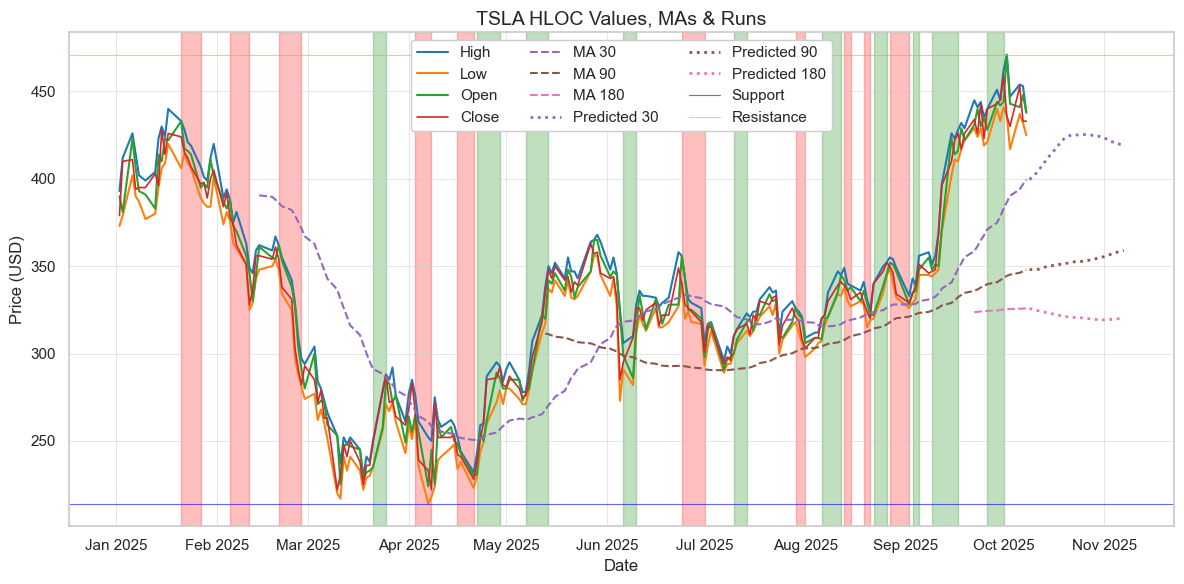

[plot_stock_data_naive] Time elapsed: 0.942536 seconds
[plot_stock_data_naive] Peak memory: 2448.37 KB


In [21]:
plot_stock_data_naive(dataset[dataset[COL_NAME] == "TSLA"])

## Optimized and modular way of plotting HLOC,MA and predictions graph

In [38]:
@measure_time_and_space
def plot_base_prices(ax, df):

    """
    Plot the base HLOC price data.
    """
    
    ax.plot(df[COL_DATE], df[COL_HIGH], label="High", color='tab:blue')
    ax.plot(df[COL_DATE], df[COL_LOW], label="Low", color='tab:orange')
    ax.plot(df[COL_DATE], df[COL_OPEN], label="Open", color='tab:green')
    ax.plot(df[COL_DATE], df[COL_CLOSE], label="Close", color='tab:red', linewidth=1.2)


@measure_time_and_space
def plot_moving_averages(ax, df):

    """
    Plot moving averages if they exist.
    """

    # Plot moving averages if they exist in the DataFrame, intended for users to see trends
    ma_colors = {
        COL_MA30: 'tab:purple',
        COL_MA90: 'tab:brown',
        COL_MA180: 'tab:pink'
    }
    for col, color in ma_colors.items():
        if col in df.columns:
            ax.plot(df[COL_DATE], df[col], label=col.replace("COL_", ""), color=color, linestyle='--')

@measure_time_and_space
def plot_predictions(ax, df, num_predictions=30):

    """
    Plot predictions using different window sizes.
    """

    # Predict using different window sizes, 30 for 1 month, 90 for 3 months, 180 for 6 months
    close_values = df[COL_CLOSE].tolist()
    last_date = df[COL_DATE].iloc[-1]
    colors = {30: 'tab:purple', 90: 'tab:brown', 180: 'tab:pink'}

    for window, color in colors.items():
        predicted = RollingMeanArray.predict(close_values, window, num_predictions)
        date_range = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=num_predictions)
        ax.plot(date_range, predicted, label=f"Predicted using {window} days", color=color, linestyle=':', linewidth=3.5)

@measure_time_and_space
def plot_support_resistance(ax, df, sr_window=60):

    """
    Compute and plot support/resistance levels.
    It uses a rolling window to determine the minimum (support) and maximum (resistance) prices over the specified period.
    """

    # Calculate support and resistance
    support = df[COL_LOW].rolling(window=sr_window, min_periods=1).min()
    resistance = df[COL_HIGH].rolling(window=sr_window, min_periods=1).max()

    support_levels = [support.tail(100).min()]
    resistance_levels = [resistance.tail(100).max()]

    for level in support_levels:
        ax.axhline(y=level, color='blue', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Support" if "Support" not in ax.get_legend_handles_labels()[1] else "")
    for level in resistance_levels:
        ax.axhline(y=level, color='orange', linestyle='-', linewidth=0.8, alpha=0.6,
                   label="Resistance" if "Resistance" not in ax.get_legend_handles_labels()[1] else "")


@measure_time_and_space
def highlight_run_segments(ax, df, min_run_length=3):

    """
    Highlight consecutive up/down runs on the chart.
    """

    df["Consecutive_Runs"] = (df["Run_Group"] != df["Run_Group"].shift()).cumsum()
    # Keep only runs meeting the minimum streak length
    run_segments = df.groupby("Consecutive_Runs").filter(lambda x: len(x) >= min_run_length)

    # Highlight upward/downward runs (drawn behind other lines)
    for _, group in run_segments.groupby("Consecutive_Runs"):
        color = (
            'green' if group["Run_Group"].iloc[0] == 1.0 else
            'red' if group["Run_Group"].iloc[0] == -1.0 else
            'gray'
        )
        ax.axvspan(group[COL_DATE].iloc[0], group[COL_DATE].iloc[-1],
                   color=color, alpha=0.25, zorder=0)


@measure_time_and_space
def format_axes(ax, df, xlabel, ylabel):
    """Format axes, labels, and grids."""
    ax.grid(True, which='major', linestyle='-', linewidth=0.5, alpha=0.7)
    ax.grid(True, which='minor', linestyle='--', linewidth=0.3, alpha=0.4)
    ax.xaxis.set_major_locator(MonthLocator())
    ax.xaxis.set_major_formatter(DateFormatter('%b %Y'))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(df[COL_NAME].iloc[0] + " HLOC Values, MAs & Runs")
    ax.legend(ncol=3)
    plt.tight_layout()


# ============================================================
# --- Main Function ---
# ============================================================

@measure_time_and_space
def plot_stock_data(df, xlabel="Date", ylabel="Price (USD)", min_run_length=3, num_predictions=30, save_fig=False, figures_folder_name = "figures"):
    
    """
    Plot stock data. Includes HLOC prices, moving averages, support/resistance levels, and highlights upward/downward runs.
    Also includes predictions for the next `num_predictions` days using rolling mean with window sizes of
    30, 90, and 180 days.
    1. HLOC prices are plotted as solid lines.
    2. Moving averages (if present) are plotted as dashed lines.
    3. Support and resistance levels are plotted as thin continuous lines.
    4. Upward/downward runs of at least `min_run_length` days are
         highlighted with shaded regions (green for upward, red for downward).
    5. Predictions for the next `num_predictions` days are plotted as dotted lines.
    Parameters:
    - df: DataFrame containing stock data with required columns.
    - xlabel: Label for the x-axis.
    - ylabel: Label for the y-axis.
    - min_run_length: Minimum length of consecutive up/down runs to highlight.
    - num_predictions: Number of days to predict using rolling mean.
    Returns:
    - None

    Note: This function uses a modularized approach for better readability and maintainability, as well as improved space and time complexity.
    """

    fig, ax = plt.subplots()

    # Modularized workflow
    plot_base_prices(ax, df)
    plot_moving_averages(ax, df)
    plot_predictions(ax, df, num_predictions=num_predictions)
    plot_support_resistance(ax, df)
    highlight_run_segments(ax, df, min_run_length=min_run_length)
    format_axes(ax, df, xlabel, ylabel)

    if save_fig:
        name = f"{df[COL_NAME].iloc[0]}"
        file_path = os.path.join(figures_folder_name, name)
        with open(file_path, 'wb') as f:
            pickle.dump(fig, f)
    plt.show()

Demonstrating performance with TSLA ticker instead of the whole dataset<br>
Total time taken for plot_stock_data to run is 0.381694 + 0.003397 + 0.002062 + 0.002857 + 0.002911 + 0.026471 + 0.192690 = <strong>0.612082s</strong><br>
Faster than plot_stock_data_naive with execution time of 0.922523s


Total memory used for plot_stock_data to run is 407.55 + 65.83 + 51.64 + 37.87 + 262.83 + 712.61 + 0 = <strong>1538.33 KB</strong>><br>
Less memory being used by plot_stock_data_naive with 2667.65 KB

[plot_base_prices] Time elapsed: 0.003882 seconds
[plot_base_prices] Peak memory: 401.57 KB
[plot_moving_averages] Time elapsed: 0.002541 seconds
[plot_moving_averages] Peak memory: 66.18 KB
[plot_predictions] Time elapsed: 0.003212 seconds
[plot_predictions] Peak memory: 51.24 KB
[plot_support_resistance] Time elapsed: 0.003233 seconds
[plot_support_resistance] Peak memory: 37.97 KB
[highlight_run_segments] Time elapsed: 0.028776 seconds
[highlight_run_segments] Peak memory: 258.73 KB
[format_axes] Time elapsed: 0.219335 seconds
[format_axes] Peak memory: 695.59 KB


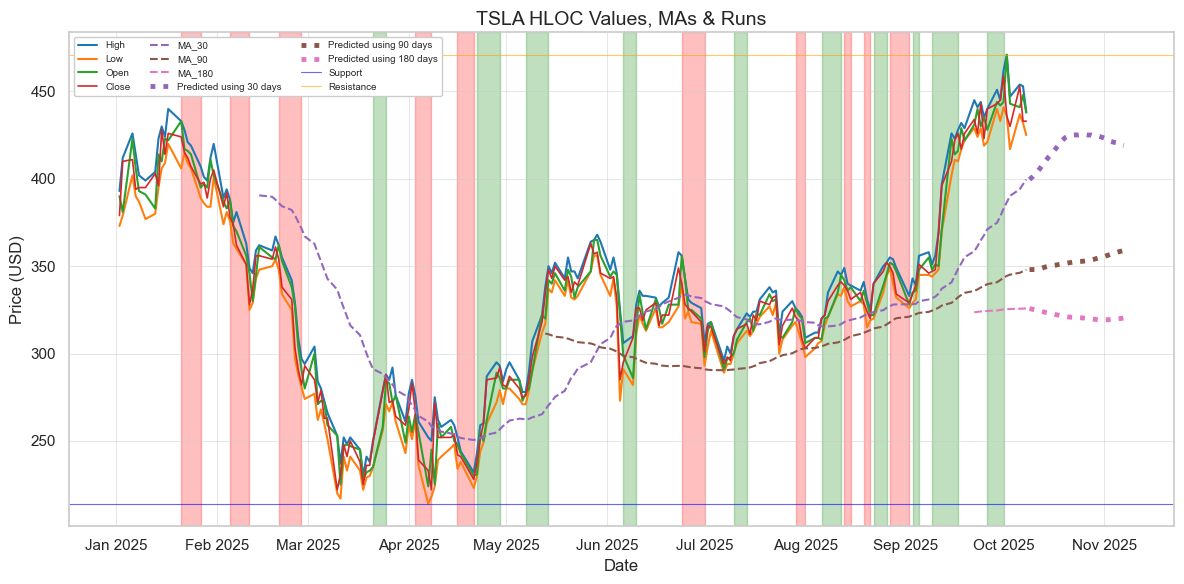

[plot_stock_data] Time elapsed: 0.417357 seconds
[plot_stock_data] Peak memory: 0.00 KB


In [39]:
plot_stock_data(dataset[dataset[COL_NAME] == "TSLA"])


📈 Plotting AAPL...
[plot_base_prices] Time elapsed: 0.004113 seconds
[plot_base_prices] Peak memory: 403.43 KB
[plot_moving_averages] Time elapsed: 0.002228 seconds
[plot_moving_averages] Peak memory: 65.85 KB
[plot_predictions] Time elapsed: 0.003020 seconds
[plot_predictions] Peak memory: 46.25 KB
[plot_support_resistance] Time elapsed: 0.003157 seconds
[plot_support_resistance] Peak memory: 37.51 KB
[highlight_run_segments] Time elapsed: 0.030348 seconds
[highlight_run_segments] Peak memory: 265.71 KB
[format_axes] Time elapsed: 0.208937 seconds
[format_axes] Peak memory: 702.51 KB


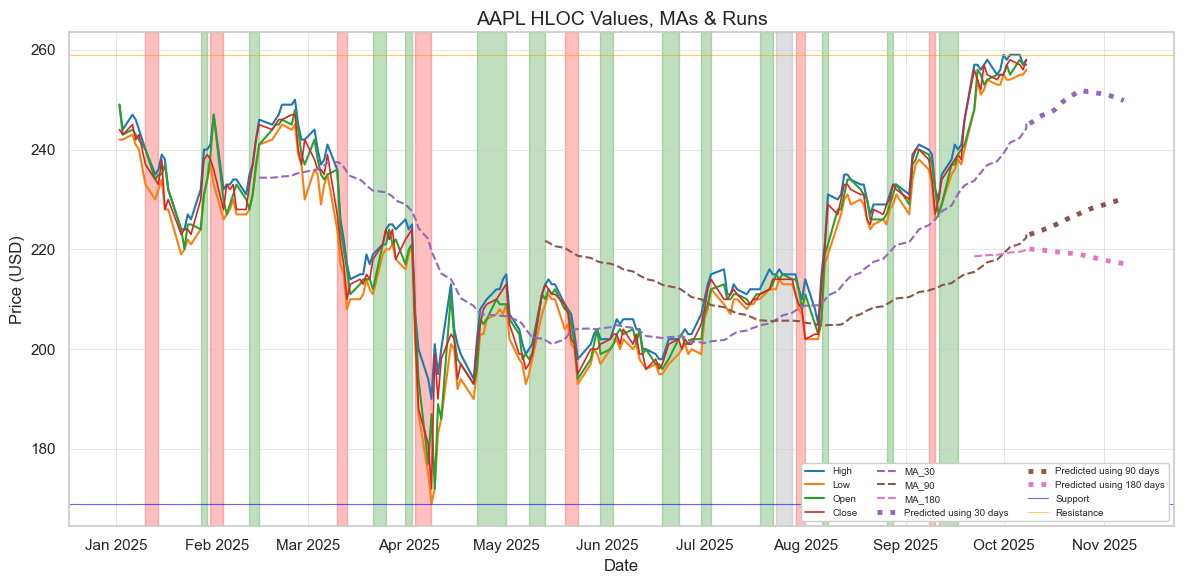

[plot_stock_data] Time elapsed: 0.416543 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting AMZN...
[plot_base_prices] Time elapsed: 0.003386 seconds
[plot_base_prices] Peak memory: 400.53 KB
[plot_moving_averages] Time elapsed: 0.002680 seconds
[plot_moving_averages] Peak memory: 65.61 KB
[plot_predictions] Time elapsed: 0.003221 seconds
[plot_predictions] Peak memory: 45.89 KB
[plot_support_resistance] Time elapsed: 0.003461 seconds
[plot_support_resistance] Peak memory: 37.90 KB
[highlight_run_segments] Time elapsed: 0.027676 seconds
[highlight_run_segments] Peak memory: 218.77 KB
[format_axes] Time elapsed: 0.210868 seconds
[format_axes] Peak memory: 692.16 KB


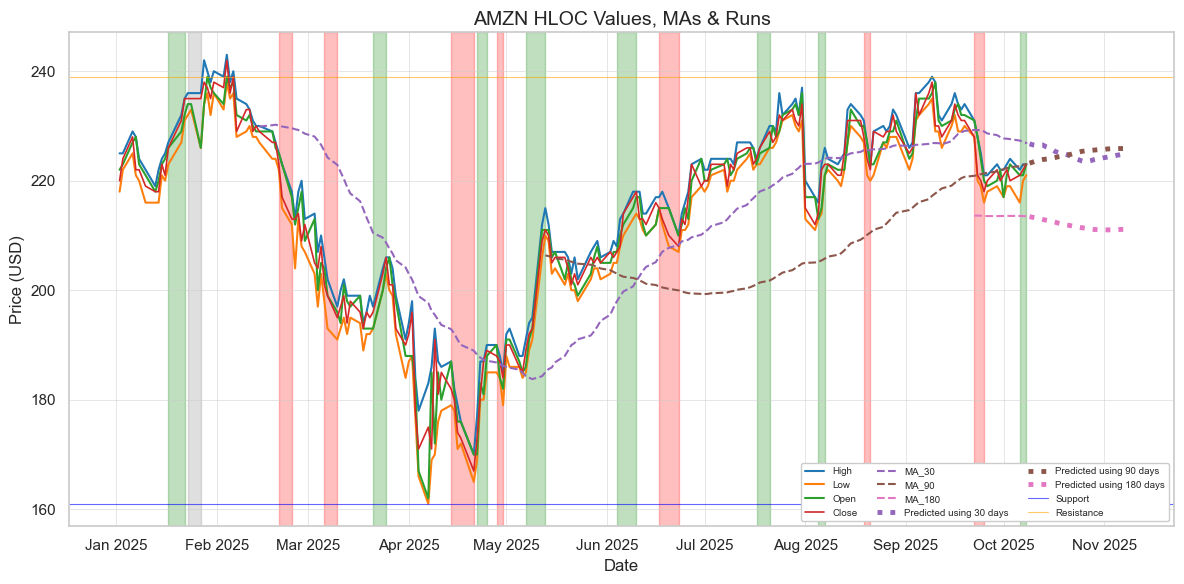

[plot_stock_data] Time elapsed: 0.411256 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting GOOGL...
[plot_base_prices] Time elapsed: 0.003782 seconds
[plot_base_prices] Peak memory: 398.37 KB
[plot_moving_averages] Time elapsed: 0.002617 seconds
[plot_moving_averages] Peak memory: 67.27 KB
[plot_predictions] Time elapsed: 0.003038 seconds
[plot_predictions] Peak memory: 45.89 KB
[plot_support_resistance] Time elapsed: 0.003403 seconds
[plot_support_resistance] Peak memory: 38.17 KB
[highlight_run_segments] Time elapsed: 0.029470 seconds
[highlight_run_segments] Peak memory: 245.34 KB
[format_axes] Time elapsed: 0.276253 seconds
[format_axes] Peak memory: 771.57 KB


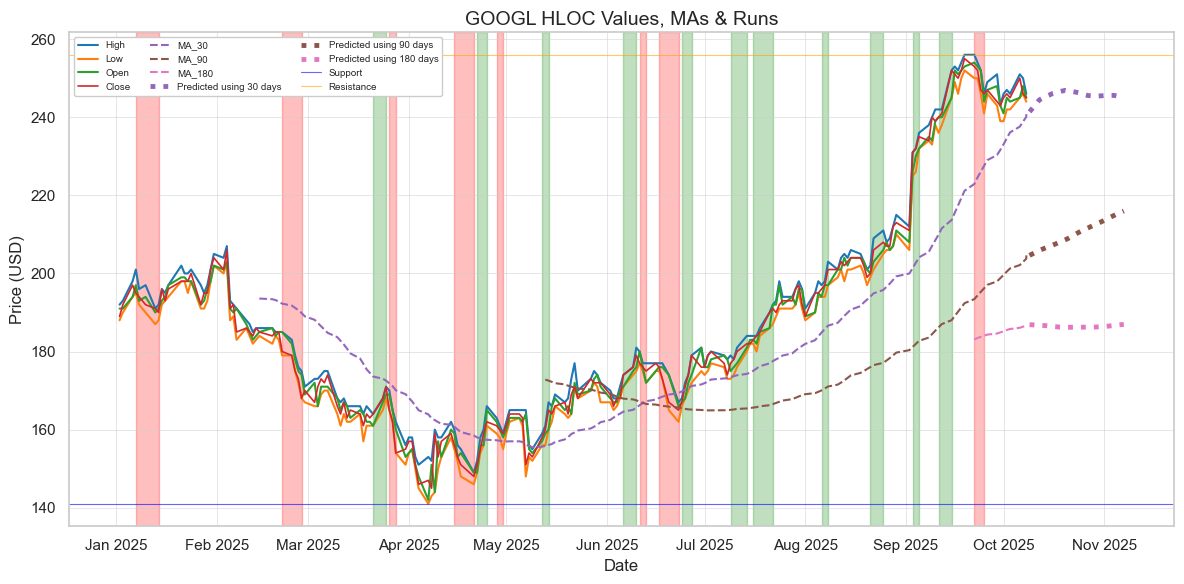

[plot_stock_data] Time elapsed: 0.483700 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting META...
[plot_base_prices] Time elapsed: 0.004559 seconds
[plot_base_prices] Peak memory: 400.14 KB
[plot_moving_averages] Time elapsed: 0.002737 seconds
[plot_moving_averages] Peak memory: 65.81 KB
[plot_predictions] Time elapsed: 0.003058 seconds
[plot_predictions] Peak memory: 52.03 KB
[plot_support_resistance] Time elapsed: 0.003225 seconds
[plot_support_resistance] Peak memory: 37.57 KB
[highlight_run_segments] Time elapsed: 0.030057 seconds
[highlight_run_segments] Peak memory: 261.75 KB
[format_axes] Time elapsed: 0.219001 seconds
[format_axes] Peak memory: 753.25 KB


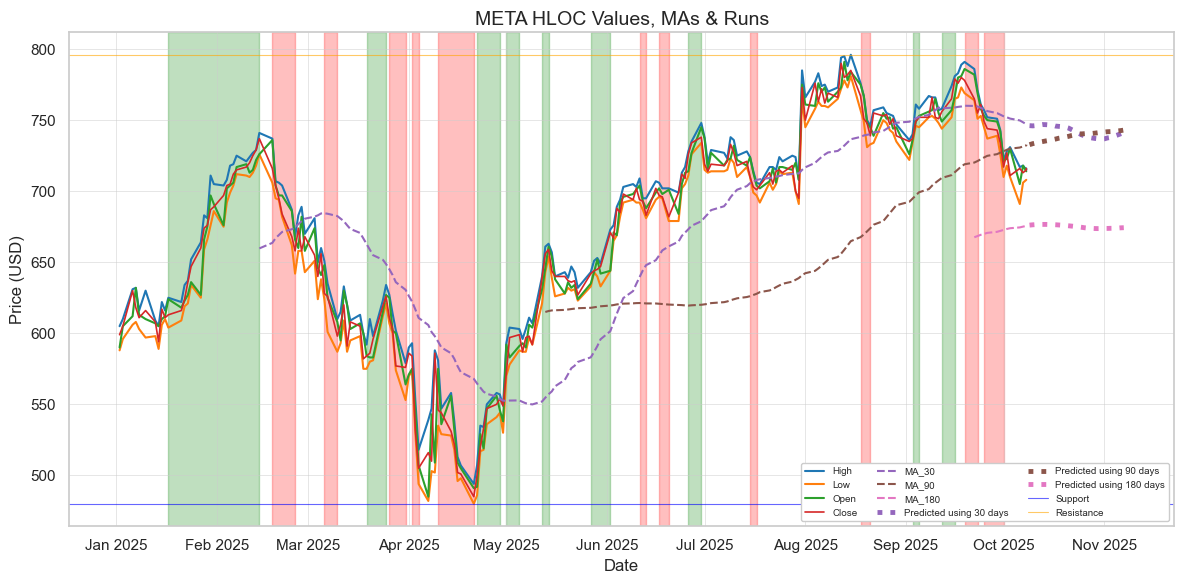

[plot_stock_data] Time elapsed: 0.429370 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting MSFT...
[plot_base_prices] Time elapsed: 0.003320 seconds
[plot_base_prices] Peak memory: 397.00 KB
[plot_moving_averages] Time elapsed: 0.002115 seconds
[plot_moving_averages] Peak memory: 66.32 KB
[plot_predictions] Time elapsed: 0.003597 seconds
[plot_predictions] Peak memory: 52.04 KB
[plot_support_resistance] Time elapsed: 0.003970 seconds
[plot_support_resistance] Peak memory: 37.69 KB
[highlight_run_segments] Time elapsed: 0.030780 seconds
[highlight_run_segments] Peak memory: 237.93 KB
[format_axes] Time elapsed: 0.221840 seconds
[format_axes] Peak memory: 696.31 KB


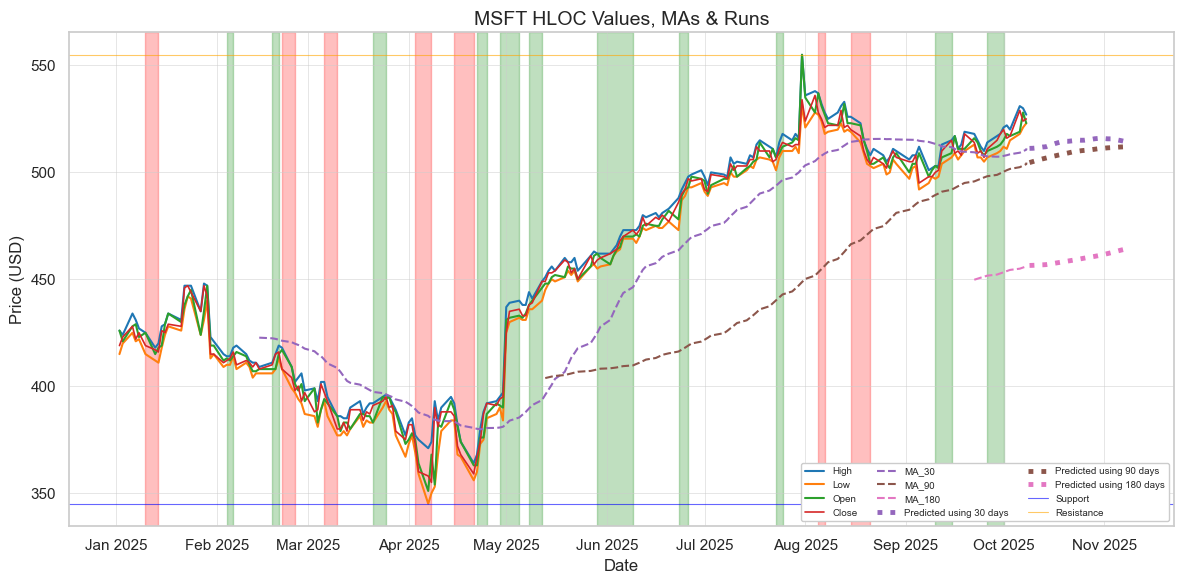

[plot_stock_data] Time elapsed: 0.430178 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting NVDA...
[plot_base_prices] Time elapsed: 0.004032 seconds
[plot_base_prices] Peak memory: 398.13 KB
[plot_moving_averages] Time elapsed: 0.002269 seconds
[plot_moving_averages] Peak memory: 65.55 KB
[plot_predictions] Time elapsed: 0.003102 seconds
[plot_predictions] Peak memory: 46.28 KB
[plot_support_resistance] Time elapsed: 0.003374 seconds
[plot_support_resistance] Peak memory: 37.41 KB
[highlight_run_segments] Time elapsed: 0.028531 seconds
[highlight_run_segments] Peak memory: 242.64 KB
[format_axes] Time elapsed: 0.209762 seconds
[format_axes] Peak memory: 695.02 KB


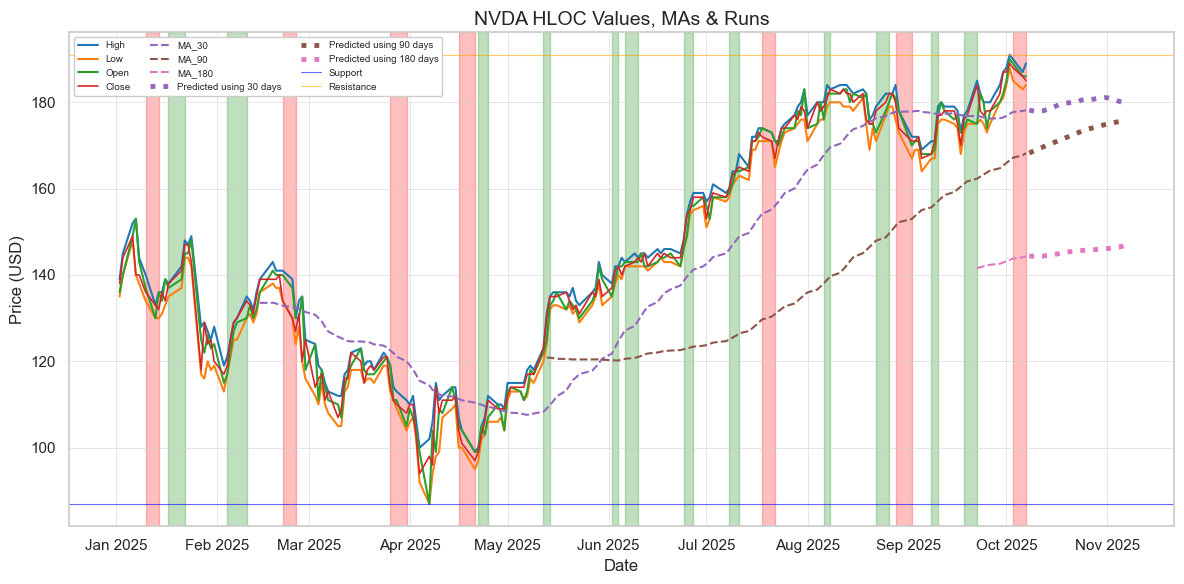

[plot_stock_data] Time elapsed: 0.412504 seconds
[plot_stock_data] Peak memory: 0.00 KB

📈 Plotting TSLA...
[plot_base_prices] Time elapsed: 0.004070 seconds
[plot_base_prices] Peak memory: 399.41 KB
[plot_moving_averages] Time elapsed: 0.002733 seconds
[plot_moving_averages] Peak memory: 65.98 KB
[plot_predictions] Time elapsed: 0.003317 seconds
[plot_predictions] Peak memory: 51.46 KB
[plot_support_resistance] Time elapsed: 0.003197 seconds
[plot_support_resistance] Peak memory: 37.66 KB
[highlight_run_segments] Time elapsed: 0.031371 seconds
[highlight_run_segments] Peak memory: 258.66 KB
[format_axes] Time elapsed: 0.211921 seconds
[format_axes] Peak memory: 699.85 KB


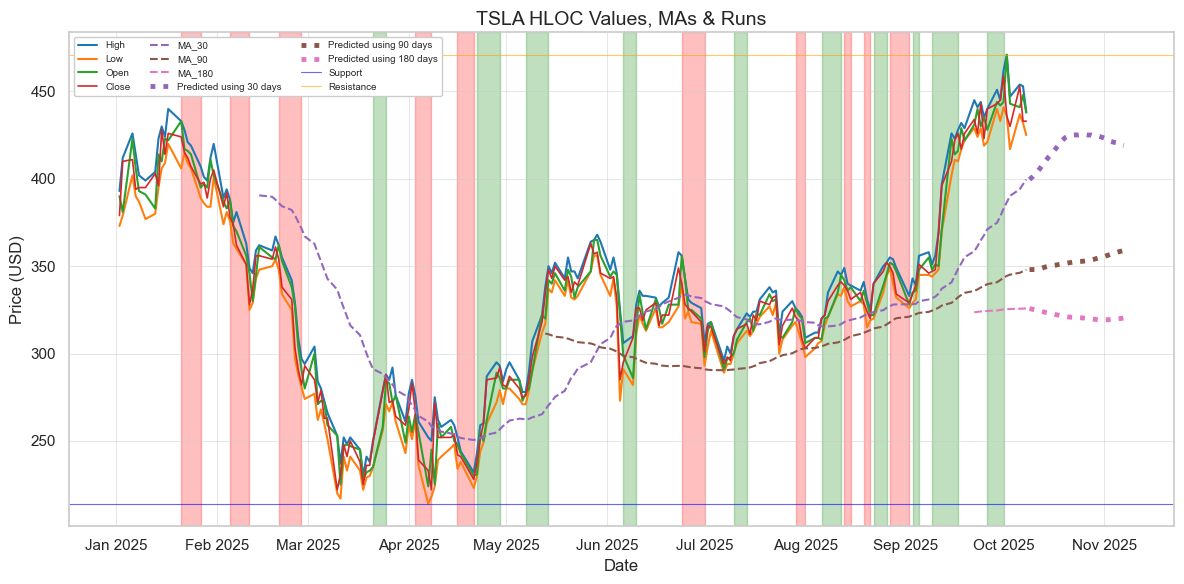

[plot_stock_data] Time elapsed: 0.421170 seconds
[plot_stock_data] Peak memory: 0.00 KB


In [40]:
# Assuming combined_df has all MAG7 stocks
for name, group in dataset.groupby(COL_NAME):
    print(f"\n📈 Plotting {name}...")
    plot_stock_data(group, save_fig=True)


## Plotting daily return distribution


📊 Plotting Daily Return Distribution for AAPL...


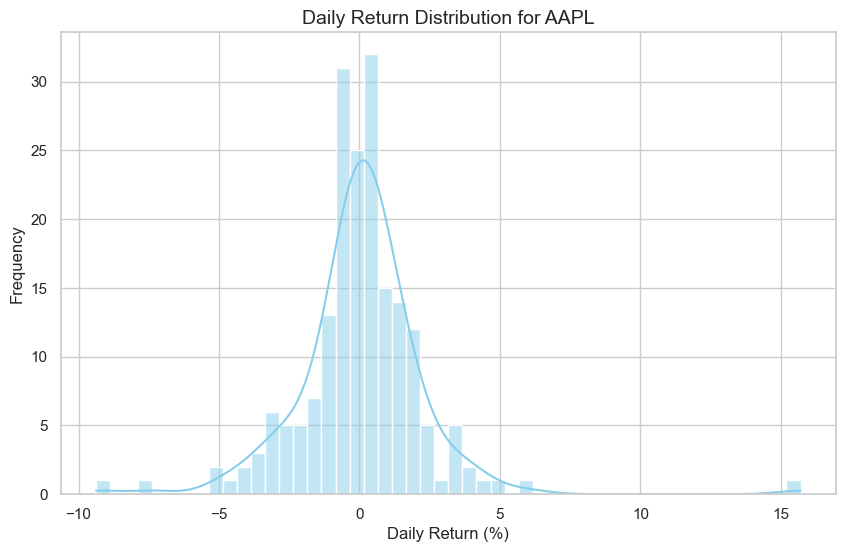


📊 Plotting Daily Return Distribution for AMZN...


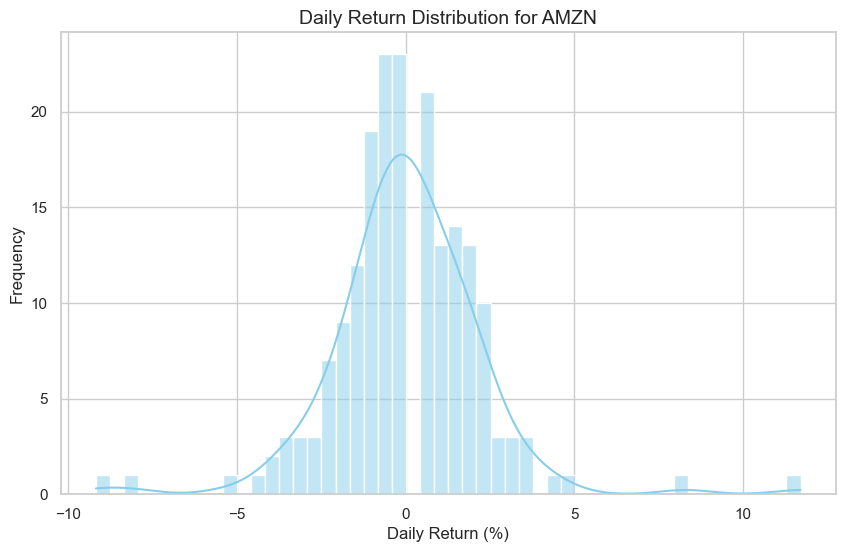


📊 Plotting Daily Return Distribution for GOOGL...


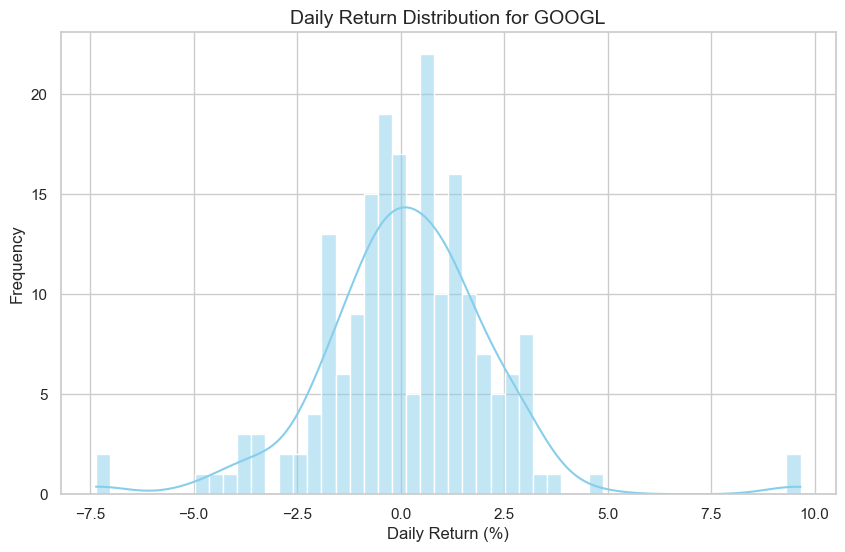


📊 Plotting Daily Return Distribution for META...


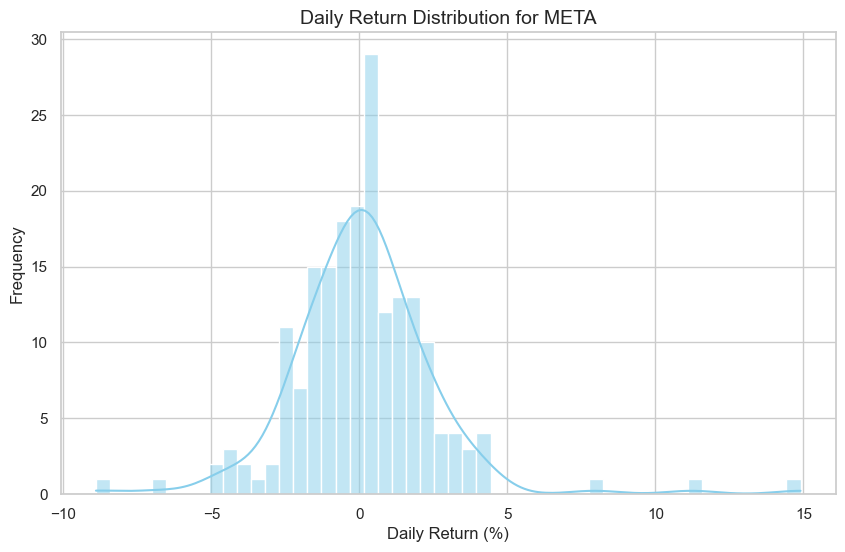


📊 Plotting Daily Return Distribution for MSFT...


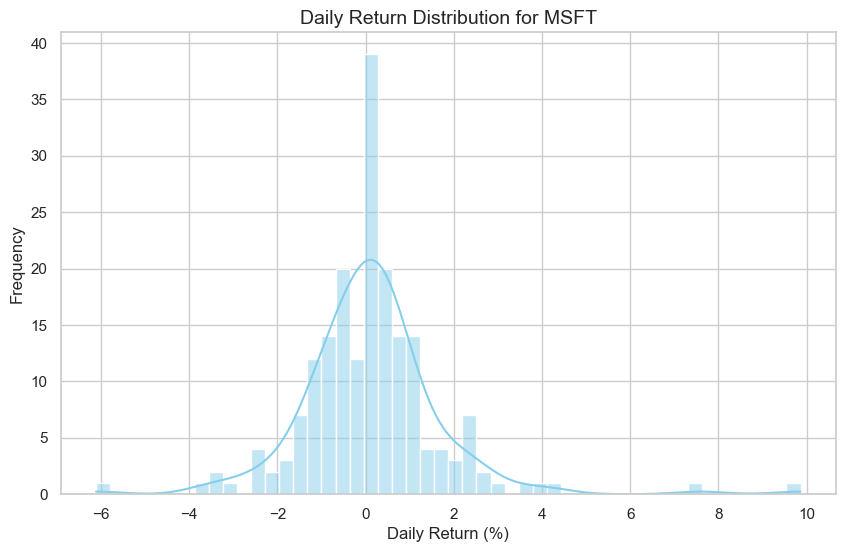


📊 Plotting Daily Return Distribution for NVDA...


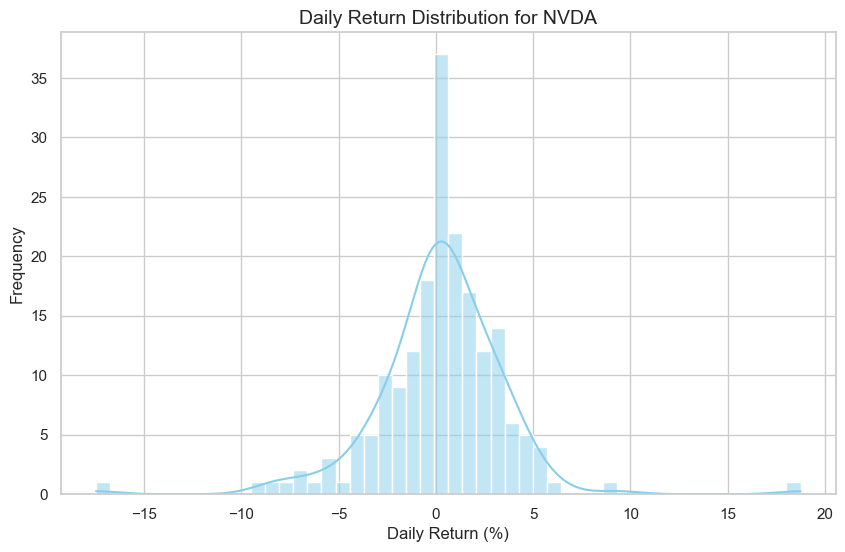


📊 Plotting Daily Return Distribution for TSLA...


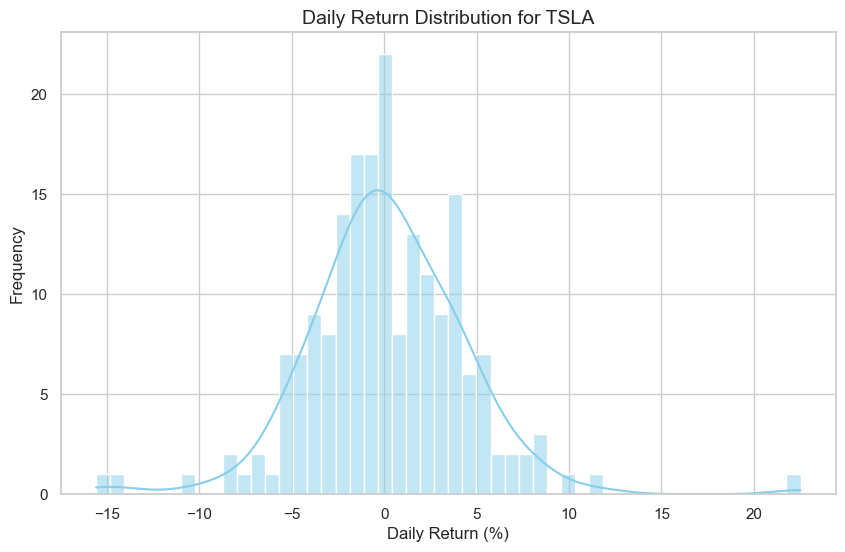

In [44]:
def plot_daily_return_distribution(df, ticker, save_fig=False, figures_folder_name = "figures"):
    """Plot the distribution of daily returns for a given stock ticker."""
    fig = plt.figure(figsize=(10, 6))
    sns.histplot(df[df[COL_NAME] == ticker][COL_DAILY_RETURN].dropna(), bins=50, kde=True, color='skyblue')
    plt.title(f'Daily Return Distribution for {ticker}')
    plt.xlabel('Daily Return (%)')
    plt.ylabel('Frequency')
    plt.grid(True)

    if save_fig:
        name = f"{ticker}_Daily_Return_Distribution"
        file_path = os.path.join(figures_folder_name, name)
        with open(file_path, 'wb') as f:
            pickle.dump(fig, f)
    plt.show()

for name in companies:
    print(f"\n📊 Plotting Daily Return Distribution for {name}...")
    plot_daily_return_distribution(dataset, name, save_fig=True)